**PREDICTIVE MODEL FOR BOSTON HOUSE PRICES**

In [6]:
!git clone https://github.com/stephiewahome-hue/daLoad Data from Google Drive

[6]
2s
Cloning into 'data-science-mining-and-warehousing'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 120 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 15.52 MiB | 15.24 MiB/s, done.
Resolving deltas: 100% (45/45), done.
total 1188
drwxr-xr-x 2 root root    4096 Jul 14 10:06  .
drwxr-xr-x 6 root root    4096 Jul 14 10:06  ..
-rw-r--r-- 1 root root     383 Jul 14 10:06  Anova.csv
-rw-r--r-- 1 root root   32374 Jul 14 10:06  BostonHousing.csv
-rw-r--r-- 1 root root   23875 Jul 14 10:06  Data-diabetes.csv
-rw-r--r-- 1 root root 1103280 Jul 14 10:06  Data-groceries.csv
-rw-r--r-- 1 root root   12580 Jul 14 10:06  employee_salary_data.csv
-rw-r--r-- 1 root root       1 Jul 14 10:06  .gitkeep
-rw-r--r-- 1 root root   19603 Jul 14 10:06 'penguins (2) (1).csv'
$0ta-science-mining-and-warehousing.git
import os
os.chdir('data-science-mining-and-warehousing')
!ls -la datasets/

Cloning into 'data-science-mining-and-warehousing'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 120 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 15.52 MiB | 15.24 MiB/s, done.
Resolving deltas: 100% (45/45), done.
total 1188
drwxr-xr-x 2 root root    4096 Jul 14 10:06  .
drwxr-xr-x 6 root root    4096 Jul 14 10:06  ..
-rw-r--r-- 1 root root     383 Jul 14 10:06  Anova.csv
-rw-r--r-- 1 root root   32374 Jul 14 10:06  BostonHousing.csv
-rw-r--r-- 1 root root   23875 Jul 14 10:06  Data-diabetes.csv
-rw-r--r-- 1 root root 1103280 Jul 14 10:06  Data-groceries.csv
-rw-r--r-- 1 root root   12580 Jul 14 10:06  employee_salary_data.csv
-rw-r--r-- 1 root root       1 Jul 14 10:06  .gitkeep
-rw-r--r-- 1 root root   19603 Jul 14 10:06 'penguins (2) (1).csv'


Import Libraries:

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

Load Data:

In [8]:
df = pd.read_csv('datasets/BostonHousing.csv')
print(df.head())
print(df.info())
print(df.describe())

      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

   LSTAT  MEDV  CAT. MEDV  
0   4.98  24.0          0  
1   9.14  21.6          0  
2   4.03  34.7          1  
3   2.94  33.4          1  
4   5.33  36.2          1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   N

Explore Data:

In [29]:
# Check your data
print("Dataset Info:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nMissing Values:")
print(df.isnull().sum())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CRIM       506 non-null    float64
 1   ZN         506 non-null    float64
 2   INDUS      506 non-null    float64
 3   CHAS       506 non-null    int64  
 4   NOX        506 non-null    float64
 5   RM         506 non-null    float64
 6   AGE        506 non-null    float64
 7   DIS        506 non-null    float64
 8   RAD        506 non-null    int64  
 9   TAX        506 non-null    int64  
 10  PTRATIO    506 non-null    float64
 11  LSTAT      506 non-null    float64
 12  MEDV       506 non-null    float64
 13  CAT. MEDV  506 non-null    int64  
dtypes: float64(10), int64(4)
memory usage: 55.5 KB
None

Statistical Summary:
             CRIM          ZN       INDUS        CHAS         NOX          RM  \
count  506.000000  506.000000  506.000000  506.000000  506.000000  506.000000   


Visualize data:

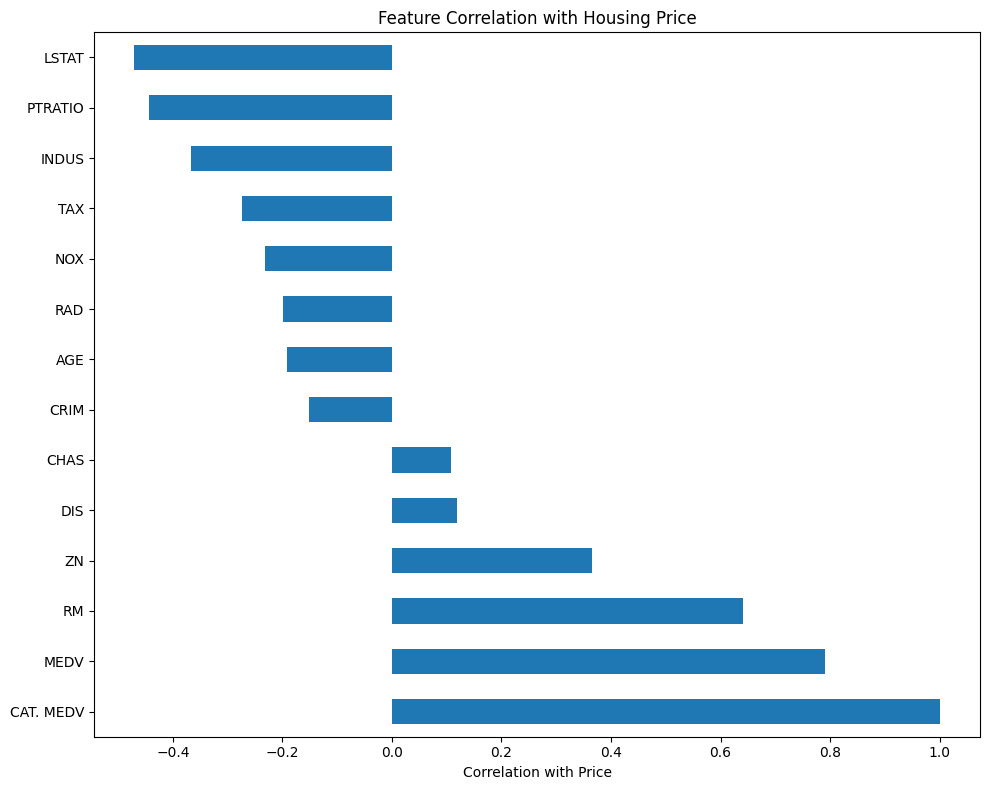

Features Most Correlated with Price:
CAT. MEDV    1.000000
MEDV         0.789789
RM           0.641265
ZN           0.365296
DIS          0.118887
CHAS         0.108631
CRIM        -0.151987
AGE         -0.191196
RAD         -0.197924
NOX         -0.232502
TAX         -0.273687
INDUS       -0.366276
PTRATIO     -0.443425
LSTAT       -0.469911
Name: CAT. MEDV, dtype: float64


In [31]:
# Plot correlation with target variable
correlation_with_target = df.corr()[df.columns[-1]].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
correlation_with_target.plot(kind='barh')
plt.xlabel('Correlation with Price')
plt.title('Feature Correlation with Housing Price')
plt.tight_layout()
plt.show()

print("Features Most Correlated with Price:")
print(correlation_with_target)

Target Variable Distribution:

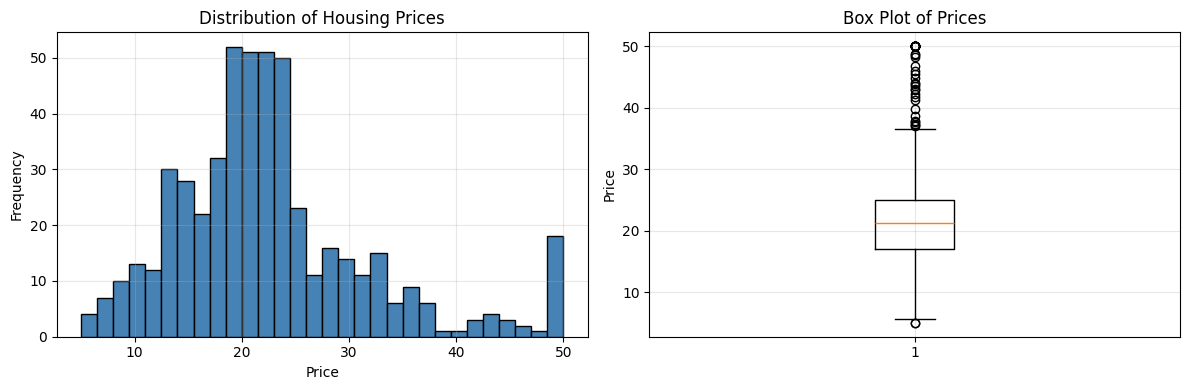

In [30]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=30, color='steelblue', edgecolor='black')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Housing Prices')
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(y)
plt.ylabel('Price')
plt.title('Box Plot of Prices')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Prepare Data:

In [9]:
X = df.drop('MEDV', axis=1)  # Features (adjust column name if different)
y = df['MEDV']  # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Train & Evaluate:


In [12]:
# Step 1: Train Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

lr_r2 = r2_score(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression:")
print(f"  R²: {lr_r2:.4f}")
print(f"  RMSE: {lr_rmse:.4f}")
print(f"  MAE: {lr_mae:.4f}")

Linear Regression:
  R²: 0.7982
  RMSE: 3.8472
  MAE: 2.6793


In [13]:
# Step 2: Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rf_r2 = r2_score(y_test, y_pred_rf)
rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_mae = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest:")
print(f"  R²: {rf_r2:.4f}")
print(f"  RMSE: {rf_rmse:.4f}")
print(f"  MAE: {rf_mae:.4f}")

Random Forest:
  R²: 0.9260
  RMSE: 2.3291
  MAE: 1.7495


In [14]:
# Step 3: Train Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

gb_r2 = r2_score(y_test, y_pred_gb)
gb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
gb_mae = mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting:")
print(f"  R²: {gb_r2:.4f}")
print(f"  RMSE: {gb_rmse:.4f}")
print(f"  MAE: {gb_mae:.4f}")

Gradient Boosting:
  R²: 0.9210
  RMSE: 2.4064
  MAE: 1.7913


Comparison table:

In [15]:
# Step 4: NOW Create Comparison Table
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R²': [lr_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'MAE': [lr_mae, rf_mae, gb_mae]
})

print("\nModel Comparison:")
print(results.to_string(index=False))


Model Comparison:
            Model       R²     RMSE      MAE
Linear Regression 0.798174 3.847166 2.679280
    Random Forest 0.926025 2.329132 1.749500
Gradient Boosting 0.921034 2.406421 1.791313


Visualize the Results:

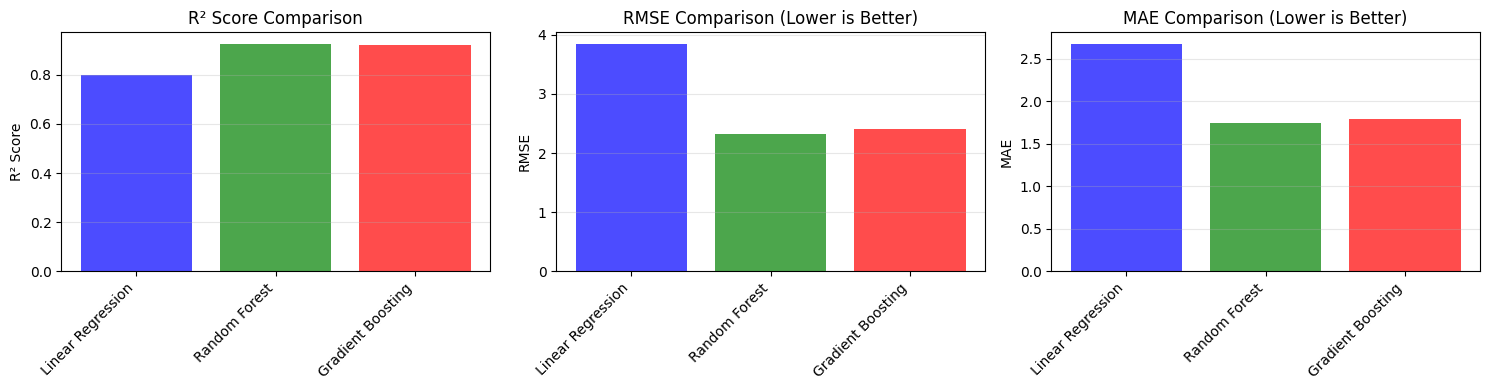

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot 1: Compare R² Scores
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = ['Linear Regression', 'Random Forest', 'Gradient Boosting']
x_pos = np.arange(len(models))

# R² Comparison
axes[0].bar(x_pos, [lr_r2, rf_r2, gb_r2], color=['blue', 'green', 'red'], alpha=0.7)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score Comparison')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].grid(alpha=0.3, axis='y')

# RMSE Comparison
axes[1].bar(x_pos, [lr_rmse, rf_rmse, gb_rmse], color=['blue', 'green', 'red'], alpha=0.7)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison (Lower is Better)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].grid(alpha=0.3, axis='y')

# MAE Comparison
axes[2].bar(x_pos, [lr_mae, rf_mae, gb_mae], color=['blue', 'green', 'red'], alpha=0.7)
axes[2].set_ylabel('MAE')
axes[2].set_title('MAE Comparison (Lower is Better)')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(models, rotation=45, ha='right')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Plot Actual vs Predicted:


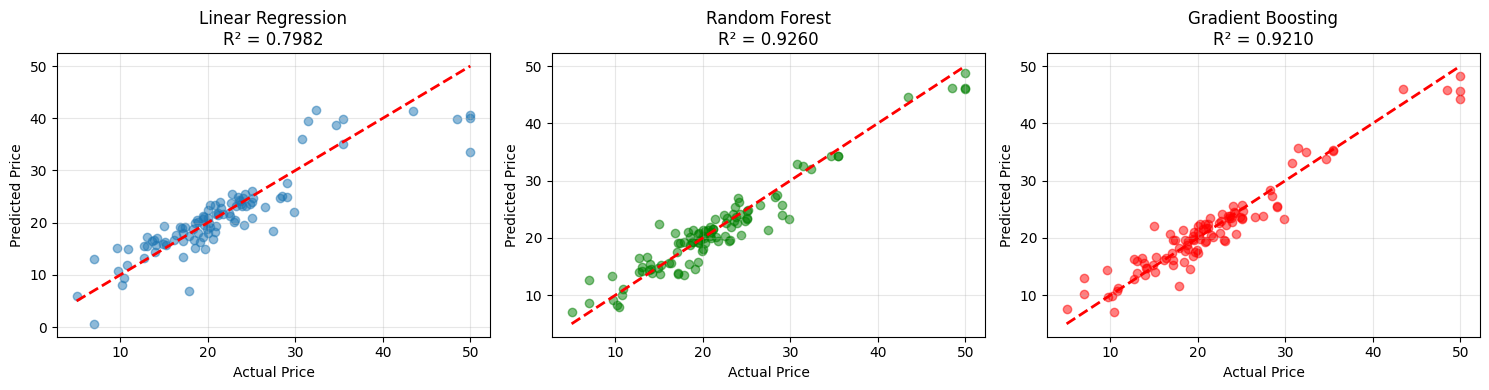

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Predicted Price')
axes[0].set_title(f'Linear Regression\nR² = {lr_r2:.4f}')
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.5, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Predicted Price')
axes[1].set_title(f'Random Forest\nR² = {rf_r2:.4f}')
axes[1].grid(alpha=0.3)

# Gradient Boosting
axes[2].scatter(y_test, y_pred_gb, alpha=0.5, color='red')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Predicted Price')
axes[2].set_title(f'Gradient Boosting\nR² = {gb_r2:.4f}')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

 Check Residuals (Prediction Errors):


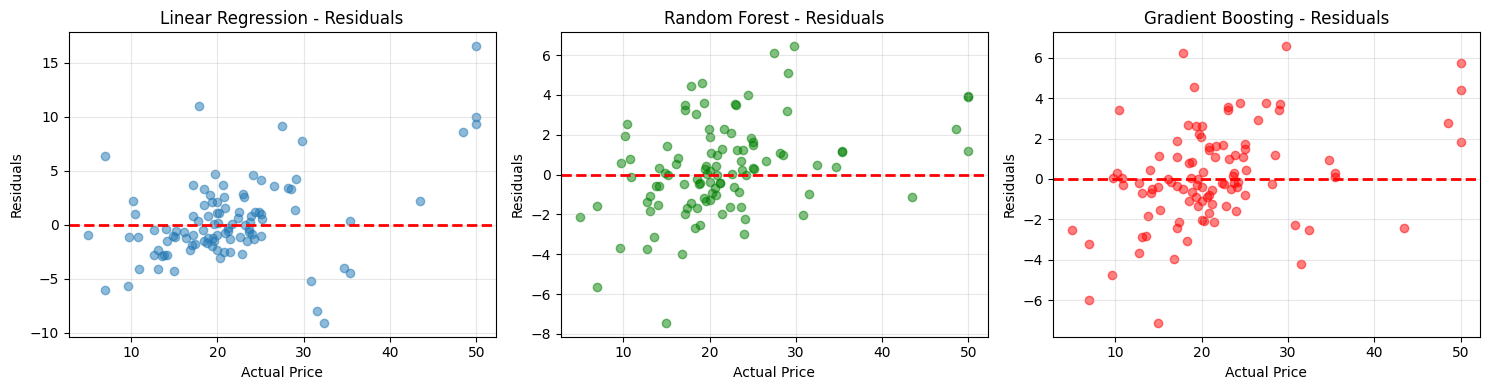

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Calculate residuals
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf
residuals_gb = y_test - y_pred_gb

# Linear Regression
axes[0].scatter(y_test, residuals_lr, alpha=0.5)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Actual Price')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Linear Regression - Residuals')
axes[0].grid(alpha=0.3)

# Random Forest
axes[1].scatter(y_test, residuals_rf, alpha=0.5, color='green')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Actual Price')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Random Forest - Residuals')
axes[1].grid(alpha=0.3)

# Gradient Boosting
axes[2].scatter(y_test, residuals_gb, alpha=0.5, color='red')
axes[2].axhline(y=0, color='r', linestyle='--', lw=2)
axes[2].set_xlabel('Actual Price')
axes[2].set_ylabel('Residuals')
axes[2].set_title('Gradient Boosting - Residuals')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Feature Importance (for Tree-based Models):

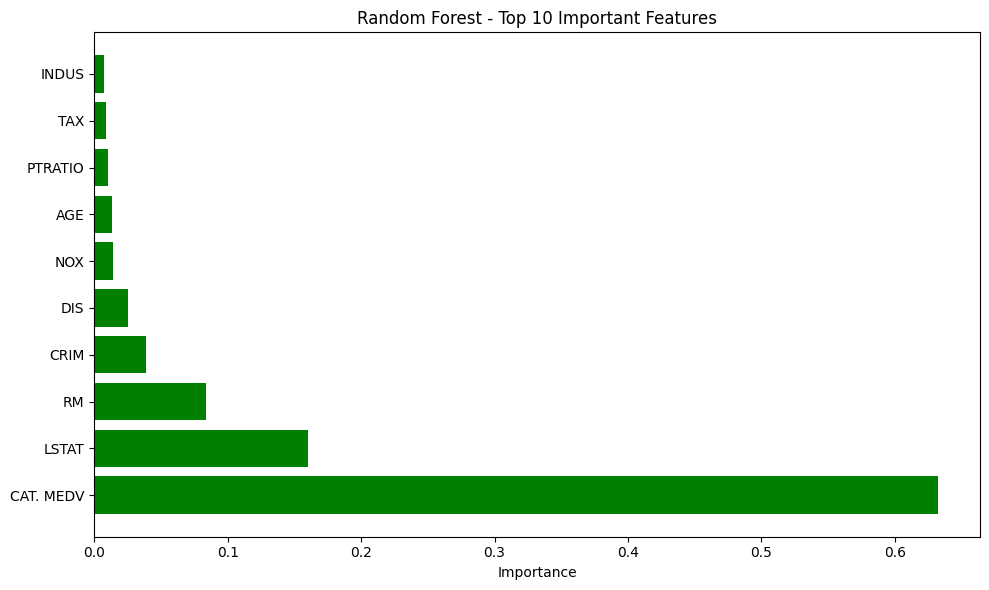

Top 10 Features (Random Forest):
  Feature  Importance
CAT. MEDV    0.632190
    LSTAT    0.159880
       RM    0.083917
     CRIM    0.039007
      DIS    0.025588
      NOX    0.014284
      AGE    0.013005
  PTRATIO    0.010446
      TAX    0.009181
    INDUS    0.007504


In [20]:
# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(rf_importance['Feature'], rf_importance['Importance'], color='green')
plt.xlabel('Importance')
plt.title('Random Forest - Top 10 Important Features')
plt.tight_layout()
plt.show()

print("Top 10 Features (Random Forest):")
print(rf_importance.to_string(index=False))

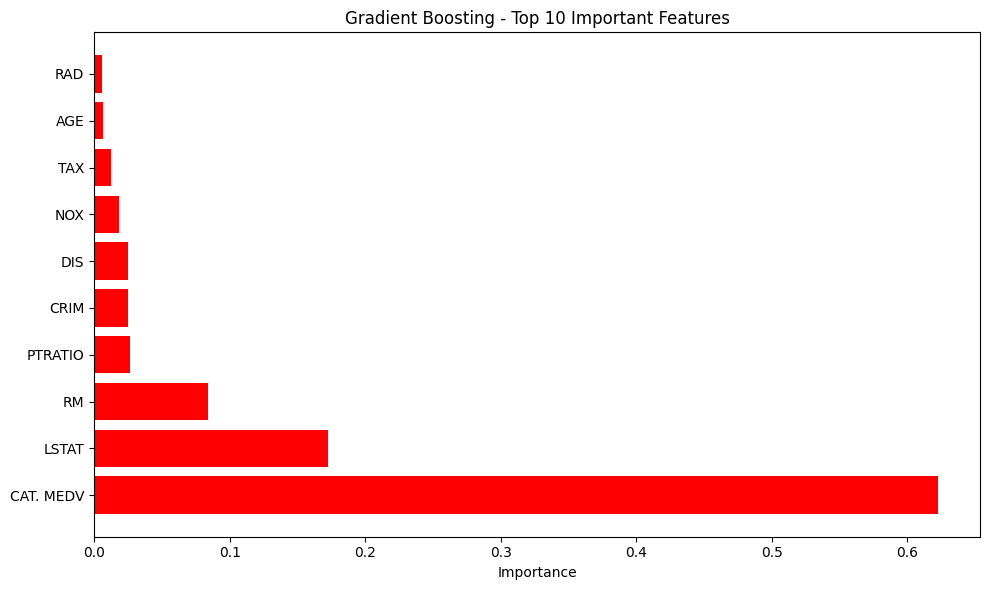

Top 10 Features (Gradient Boosting):
  Feature  Importance
CAT. MEDV    0.622492
    LSTAT    0.172792
       RM    0.083838
  PTRATIO    0.026330
     CRIM    0.024891
      DIS    0.024563
      NOX    0.018102
      TAX    0.012207
      AGE    0.006729
      RAD    0.005827


In [21]:
# Gradient Boosting Feature Importance
gb_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': gb.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(gb_importance['Feature'], gb_importance['Importance'], color='red')
plt.xlabel('Importance')
plt.title('Gradient Boosting - Top 10 Important Features')
plt.tight_layout()
plt.show()

print("Top 10 Features (Gradient Boosting):")
print(gb_importance.to_string(index=False))

Cross-Validation (to verify model stability):

In [32]:
from sklearn.model_selection import cross_val_score

# 5-fold cross-validation
lr_cv = cross_val_score(LinearRegression(), X_train, y_train, cv=5, scoring='r2')
rf_cv = cross_val_score(RandomForestRegressor(n_estimators=100, random_state=42), X_train, y_train, cv=5, scoring='r2')
gb_cv = cross_val_score(GradientBoostingRegressor(n_estimators=100, random_state=42), X_train, y_train, cv=5, scoring='r2')

print("Cross-Validation Results (5-Fold):")
print(f"Linear Regression: {lr_cv.mean():.4f} (+/- {lr_cv.std():.4f})")
print(f"Random Forest: {rf_cv.mean():.4f} (+/- {rf_cv.std():.4f})")
print(f"Gradient Boosting: {gb_cv.mean():.4f} (+/- {gb_cv.std():.4f})")

Cross-Validation Results (5-Fold):
Linear Regression: 0.8318 (+/- 0.0288)
Random Forest: 0.9051 (+/- 0.0249)
Gradient Boosting: 0.9072 (+/- 0.0236)


Summary & Conclusions:

In [25]:
best_model = results.loc[results['R2'].idxmax()]

In [26]:
# Create Comparison Table with simple column names
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R2': [lr_r2, rf_r2, gb_r2],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse],
    'MAE': [lr_mae, rf_mae, gb_mae]
})

print("\nModel Comparison:")
print(results.to_string(index=False))


Model Comparison:
            Model       R2     RMSE      MAE
Linear Regression 0.798174 3.847166 2.679280
    Random Forest 0.926025 2.329132 1.749500
Gradient Boosting 0.921034 2.406421 1.791313


In [27]:
print("\n" + "="*70)
print("FINAL RESULTS & RECOMMENDATIONS")
print("="*70)

# Find best model
best_model = results.loc[results['R2'].idxmax()]
print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"   R2 Score: {best_model['R2']:.4f}")
print(f"   RMSE: {best_model['RMSE']:.4f}")
print(f"   MAE: {best_model['MAE']:.4f}")

print("\n📊 ALL MODELS RANKED (by R2):")
for idx, row in results.sort_values('R2', ascending=False).iterrows():
    print(f"   {idx+1}. {row['Model']}: R2 = {row['R2']:.4f}, RMSE = {row['RMSE']:.4f}")

print("\n✅ KEY INSIGHTS:")
print(f"   • Best model explains {best_model['R2']*100:.1f}% of price variance")
print(f"   • Average prediction error: ${best_model['MAE']:.2f}")
print(f"   • Dataset has {len(X.columns)} features")
print(f"   • Test set has {len(y_test)} samples")

print("\n💡 RECOMMENDATION:")
print(f"   Use {best_model['Model']} for production")

print("="*70)


FINAL RESULTS & RECOMMENDATIONS

🏆 BEST MODEL: Random Forest
   R2 Score: 0.9260
   RMSE: 2.3291
   MAE: 1.7495

📊 ALL MODELS RANKED (by R2):
   2. Random Forest: R2 = 0.9260, RMSE = 2.3291
   3. Gradient Boosting: R2 = 0.9210, RMSE = 2.4064
   1. Linear Regression: R2 = 0.7982, RMSE = 3.8472

✅ KEY INSIGHTS:
   • Best model explains 92.6% of price variance
   • Average prediction error: $1.75
   • Dataset has 13 features
   • Test set has 102 samples

💡 RECOMMENDATION:
   Use Random Forest for production


In [33]:
# Step 1: Configure Git
!git config --global user.email "stephiewahome@gmail.com"
!git config --global user.name "stephiewahome-hue"

In [34]:
# Step 2: Clone your repo (if not already cloned)
!git clone https://github.com/stephiewahome-hue/data-science-mining-and-warehousing.git

Cloning into 'data-science-mining-and-warehousing'...
remote: Enumerating objects: 120, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 120 (delta 45), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (120/120), 15.52 MiB | 14.53 MiB/s, done.
Resolving deltas: 100% (45/45), done.


In [35]:
import os
os.chdir('data-science-mining-and-warehousing')


In [36]:
# Step 3: Copy notebook to notebooks folder
!cp ../Housing_Price_Prediction.ipynb notebooks/

cp: cannot stat '../Housing_Price_Prediction.ipynb': No such file or directory


In [37]:
# Step 4: Add to Git
!git add notebooks/Housing_Price_Prediction.ipynb


fatal: pathspec 'notebooks/Housing_Price_Prediction.ipynb' did not match any files
